# BLOCK-7B: Model Benchmarking, Stress Testing & Final Validation (PRO MODE)

**Role**: Senior ML Engineer performing final pre-deployment validation

**Mission**: Prove the Champion XGBoost model from BLOCK-7A:
- ✓ Generalizes to unseen data
- ✓ Is stable across data segments
- ✓ Does not hide silent failure modes

**Constraints**: NO retraining. Test set evaluation ONCE only.

---

## Setup & Dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from scipy import stats
import shap
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All dependencies loaded")
print(f"Validation Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✓ All dependencies loaded
Validation Started: 2026-01-14 17:18:55


/home/bobur/AI_Project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Loading & Time-Aware Split (70/15/15)

In [2]:
# Load Data
df = pd.read_csv('../Dataset/model_ready_data.csv')

# Strict Temporal Sorting
df['order_date'] = pd.to_datetime(df['order_date'])
df = df.sort_values(by='order_date').reset_index(drop=True)

# Feature Definitions
TARGET = "delivery_time_hours"
DROP_COLS = ['route_id', 'destination_city', 'order_date', TARGET]
CAT_FEATURES = ['traffic_level', 'weather', 'vehicle_type']
NUM_FEATURES = [c for c in df.columns if c not in CAT_FEATURES + DROP_COLS]

# Time-Aware Split 70/15/15
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print(f"Train: {len(train_df):,} samples (70%)")
print(f"Val:   {len(val_df):,} samples (15%)")
print(f"Test:  {len(test_df):,} samples (15%)")
print(f"\nTemporal Order Check:")
print(f"  Train: {train_df['order_date'].min()} → {train_df['order_date'].max()}")
print(f"  Val:   {val_df['order_date'].min()} → {val_df['order_date'].max()}")
print(f"  Test:  {test_df['order_date'].min()} → {test_df['order_date'].max()}")

# Verify no leakage
assert train_df['order_date'].max() <= val_df['order_date'].min(), "LEAKAGE: Train-Val overlap!"
assert val_df['order_date'].max() <= test_df['order_date'].min(), "LEAKAGE: Val-Test overlap!"
print("✓ Temporal integrity verified")

Train: 48,948 samples (70%)
Val:   10,489 samples (15%)
Test:  10,489 samples (15%)

Temporal Order Check:
  Train: 2025-11-06 00:00:00 → 2025-12-18 00:00:00
  Val:   2025-12-18 00:00:00 → 2025-12-27 00:00:00
  Test:  2025-12-27 00:00:00 → 2026-01-05 00:00:00
✓ Temporal integrity verified


## Preprocessing Pipeline (Fit on Train Only)

In [3]:
# Build Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUM_FEATURES),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), CAT_FEATURES)
    ],
    verbose_feature_names_out=False
)

# Fit on Train, Transform All Splits
X_train = preprocessor.fit_transform(train_df.drop(columns=DROP_COLS))
y_train = train_df[TARGET].values

X_val = preprocessor.transform(val_df.drop(columns=DROP_COLS))
y_val = val_df[TARGET].values

X_test = preprocessor.transform(test_df.drop(columns=DROP_COLS))
y_test = test_df[TARGET].values

# Get feature names for later use
feature_names = preprocessor.get_feature_names_out()

print(f"Feature Space: {X_train.shape[1]} features")
print(f"✓ Preprocessing complete")

Feature Space: 18 features
✓ Preprocessing complete


## Champion Model Training (BLOCK-7A Configuration)

Recreating the Champion XGBoost model with BLOCK-7A parameters.

In [4]:
# Champion Model Configuration
champion_params = {
    'n_estimators': 300,
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'objective': 'reg:absoluteerror',
    'n_jobs': -1,
    'random_state': 42,
    'early_stopping_rounds': 50
}

# Train Champion Model
print("Training Champion XGBoost...")
champion = XGBRegressor(**champion_params)
champion.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)

# Training Metrics
train_mae = mean_absolute_error(y_train, champion.predict(X_train))
val_mae = mean_absolute_error(y_val, champion.predict(X_val))

print(f"\nChampion Model Trained:")
print(f"  Train MAE: {train_mae:.4f}")
print(f"  Val MAE:   {val_mae:.4f}")
print(f"  Best Iteration: {champion.best_iteration}")
print("✓ Champion model ready for validation")

Training Champion XGBoost...



Champion Model Trained:
  Train MAE: 0.2266
  Val MAE:   0.2341
  Best Iteration: 295
✓ Champion model ready for validation


---
# OBJECTIVE 1: Final Test Set Evaluation (HARD GATE)

**Decision Rule**: Test MAE ≤ Val MAE + 5%

**One-shot evaluation** on the untouched test set.

In [5]:
# Test Set Predictions (ONCE ONLY)
y_pred_test = champion.predict(X_test)

# Core Metrics
test_mae = mean_absolute_error(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_r2 = r2_score(y_test, y_pred_test)

# Error Distribution
errors = np.abs(y_test - y_pred_test)
p50_error = np.percentile(errors, 50)
p75_error = np.percentile(errors, 75)
p90_error = np.percentile(errors, 90)

# HARD GATE CHECK
threshold = val_mae * 1.05  # Val MAE + 5%
gate_passed = test_mae <= threshold

print("="*60)
print("OBJECTIVE 1: TEST SET EVALUATION")
print("="*60)
print(f"\nCore Metrics:")
print(f"  MAE:  {test_mae:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  R²:   {test_r2:.4f}")
print(f"\nError Distribution:")
print(f"  P50 (Median): {p50_error:.4f}")
print(f"  P75:          {p75_error:.4f}")
print(f"  P90:          {p90_error:.4f}")
print(f"\nHARD GATE CHECK:")
print(f"  Validation MAE: {val_mae:.4f}")
print(f"  Test MAE:       {test_mae:.4f}")
print(f"  Threshold (Val + 5%): {threshold:.4f}")
print(f"  Status: {'✅ PASSED' if gate_passed else '❌ FAILED - FLAG AS RISK'}")

# Create metrics table
metrics_table = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²', 'P50 Error', 'P75 Error', 'P90 Error'],
    'Value': [test_mae, test_rmse, test_r2, p50_error, p75_error, p90_error]
})
print(f"\nTest Set Metrics Table:")
print(metrics_table.to_string(index=False))

OBJECTIVE 1: TEST SET EVALUATION

Core Metrics:
  MAE:  0.2294
  RMSE: 0.3216
  R²:   0.9971

Error Distribution:
  P50 (Median): 0.1514
  P75:          0.3343
  P90:          0.5485

HARD GATE CHECK:
  Validation MAE: 0.2341
  Test MAE:       0.2294
  Threshold (Val + 5%): 0.2458
  Status: ✅ PASSED

Test Set Metrics Table:
   Metric    Value
      MAE 0.229374
     RMSE 0.321641
       R² 0.997127
P50 Error 0.151369
P75 Error 0.334328
P90 Error 0.548531


---
# OBJECTIVE 2: Residual Diagnostics (Failure Mode Detection)

In [6]:
# Compute residuals
residuals = y_test - y_pred_test

# Statistical Tests
mean_residual = np.mean(residuals)
std_residual = np.std(residuals)
skewness = stats.skew(residuals)
kurtosis = stats.kurtosis(residuals)

# Bias Check (systematic under/over-prediction)
bias_pct = (mean_residual / np.mean(y_test)) * 100
has_bias = abs(bias_pct) > 2  # >2% is significant

# Heteroskedasticity Check (Breusch-Pagan-like)
# Split predictions into quartiles and compare variance
pred_quartiles = pd.qcut(y_pred_test, q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
variance_by_quartile = pd.DataFrame({
    'Quartile': pred_quartiles,
    'Residual': residuals
}).groupby('Quartile')['Residual'].var()

variance_ratio = variance_by_quartile.max() / variance_by_quartile.min()
has_heteroskedasticity = variance_ratio > 3  # 3x variance difference

# Outlier Density (>3σ)
outlier_threshold = 3 * std_residual
outliers = np.abs(residuals) > outlier_threshold
outlier_pct = (outliers.sum() / len(residuals)) * 100

print("="*60)
print("OBJECTIVE 2: RESIDUAL DIAGNOSTICS")
print("="*60)
print(f"\nStatistical Summary:")
print(f"  Mean Residual:  {mean_residual:.4f} ({bias_pct:+.2f}% of avg target)")
print(f"  Std Residual:   {std_residual:.4f}")
print(f"  Skewness:       {skewness:.4f}")
print(f"  Kurtosis:       {kurtosis:.4f}")
print(f"\nFailure Mode Checks:")
print(f"  Bias (systematic): {'⚠️ DETECTED' if has_bias else '✓ None'} (|{bias_pct:.2f}%| {'>' if has_bias else '≤'} 2%)")
print(f"  Heteroskedasticity: {'⚠️ DETECTED' if has_heteroskedasticity else '✓ None'} (Var ratio: {variance_ratio:.2f})")
print(f"  Outliers (>3σ):     {outliers.sum()} samples ({outlier_pct:.2f}%)")

# Engineering Summary
print(f"\nEngineering Interpretation:")
if not has_bias and not has_heteroskedasticity and outlier_pct < 1:
    print("  ✅ Residuals well-behaved. No systematic failures detected.")
else:
    if has_bias:
        print(f"  ⚠️ Model shows {'positive' if mean_residual > 0 else 'negative'} bias.")
    if has_heteroskedasticity:
        print("  ⚠️ Variance increases with prediction magnitude (heteroskedasticity).")
    if outlier_pct > 1:
        print(f"  ⚠️ High outlier density ({outlier_pct:.2f}%). Investigate edge cases.")

OBJECTIVE 2: RESIDUAL DIAGNOSTICS

Statistical Summary:
  Mean Residual:  0.0001 (+0.00% of avg target)
  Std Residual:   0.3216
  Skewness:       -0.0219
  Kurtosis:       1.7680

Failure Mode Checks:
  Bias (systematic): ✓ None (|0.00%| ≤ 2%)
  Heteroskedasticity: ⚠️ DETECTED (Var ratio: 45.65)
  Outliers (>3σ):     111 samples (1.06%)

Engineering Interpretation:
  ⚠️ Variance increases with prediction magnitude (heteroskedasticity).
  ⚠️ High outlier density (1.06%). Investigate edge cases.


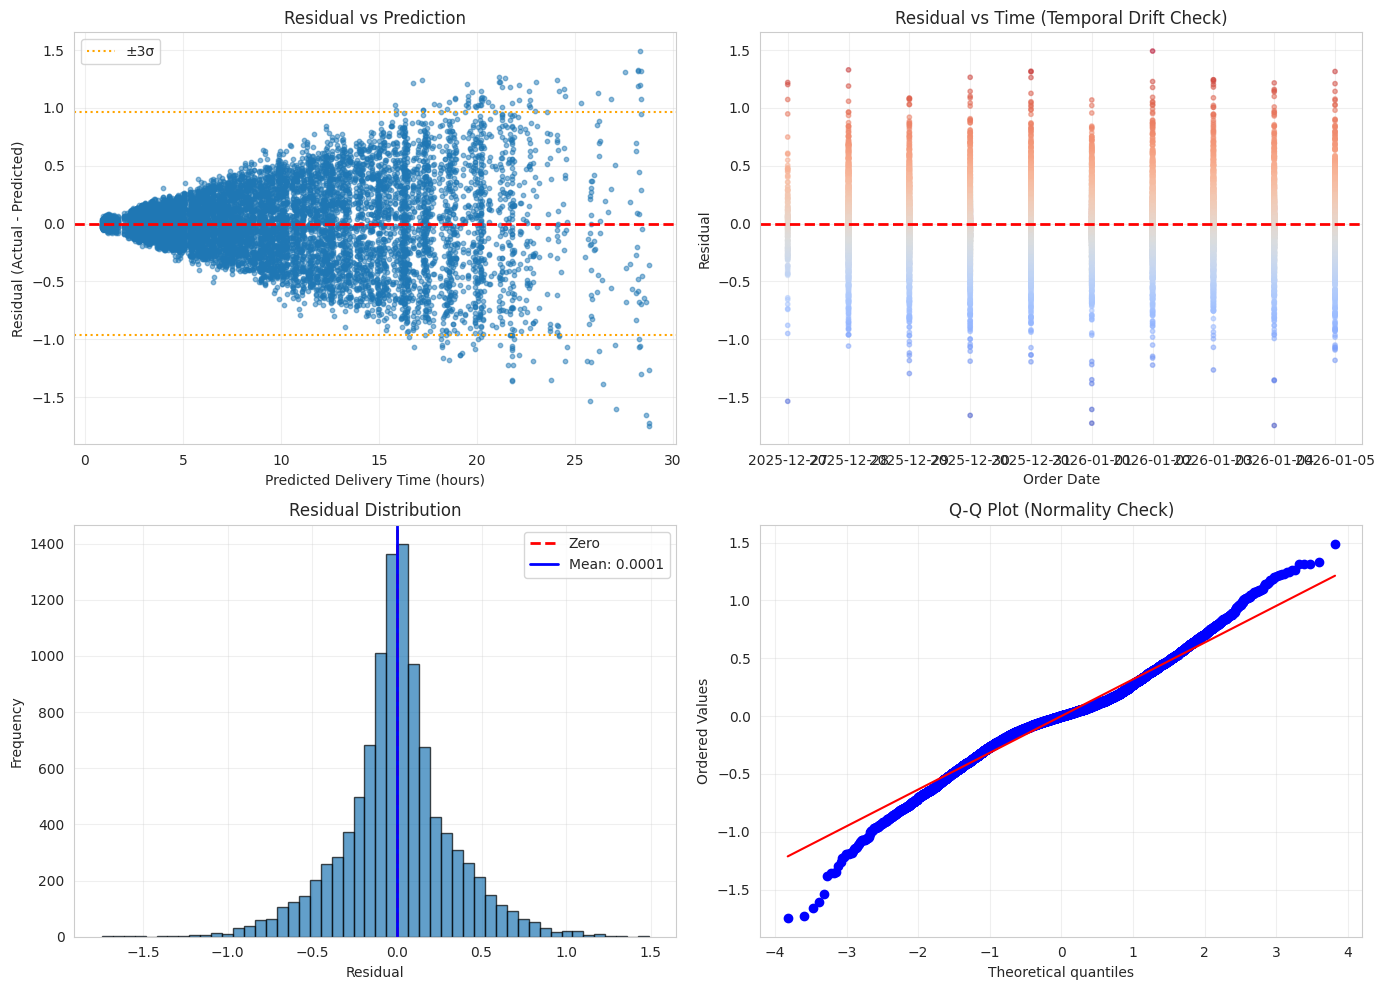

✓ Residual diagnostic plots generated


In [7]:
# Visualization: Residual Diagnostics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residual vs Prediction
axes[0, 0].scatter(y_pred_test, residuals, alpha=0.5, s=10)
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0, 0].axhline(outlier_threshold, color='orange', linestyle=':', label='±3σ')
axes[0, 0].axhline(-outlier_threshold, color='orange', linestyle=':')
axes[0, 0].set_xlabel('Predicted Delivery Time (hours)')
axes[0, 0].set_ylabel('Residual (Actual - Predicted)')
axes[0, 0].set_title('Residual vs Prediction')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Residual vs Time (Temporal Drift)
test_dates = test_df['order_date'].values
axes[0, 1].scatter(test_dates, residuals, alpha=0.5, s=10, c=residuals, cmap='coolwarm')
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Order Date')
axes[0, 1].set_ylabel('Residual')
axes[0, 1].set_title('Residual vs Time (Temporal Drift Check)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Residual Distribution
axes[1, 0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero')
axes[1, 0].axvline(mean_residual, color='blue', linestyle='-', linewidth=2, label=f'Mean: {mean_residual:.4f}')
axes[1, 0].set_xlabel('Residual')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Residual Distribution')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Q-Q Plot (Normality Check)
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normality Check)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Residual diagnostic plots generated")

---
# OBJECTIVE 3: Segment-Level Performance Stress Test

**Decision Rule**: No segment MAE > 1.5× global test MAE

In [8]:
# Add predictions to test dataframe for slicing
test_df_eval = test_df.copy()
test_df_eval['prediction'] = y_pred_test
test_df_eval['error'] = np.abs(y_test - y_pred_test)

# Define peak hours (7-9 AM, 5-7 PM)
test_df_eval['hour'] = pd.to_datetime(test_df_eval['order_date']).dt.hour
test_df_eval['peak_hours'] = test_df_eval['hour'].apply(
    lambda h: 'Peak' if (7 <= h <= 9) or (17 <= h <= 19) else 'Non-Peak'
)

# Global MAE (reference)
global_mae = test_mae
threshold_1_5x = global_mae * 1.5

# Compute segment-level MAE
segments = {
    'Traffic Level': 'traffic_level',
    'Weather': 'weather',
    'Vehicle Type': 'vehicle_type',
    'Peak Hours': 'peak_hours'
}

segment_results = []
print("="*60)
print("OBJECTIVE 3: SEGMENT-LEVEL STRESS TEST")
print("="*60)
print(f"\nGlobal Test MAE: {global_mae:.4f}")
print(f"Threshold (1.5× Global): {threshold_1_5x:.4f}")
print("\nSegment Performance:")
print("-" * 60)

for seg_name, seg_col in segments.items():
    seg_groups = test_df_eval.groupby(seg_col)['error'].agg(['mean', 'count'])
    seg_groups.columns = ['MAE', 'Count']
    seg_groups = seg_groups.reset_index()
    seg_groups.columns = ['Segment', 'MAE', 'Count']
    seg_groups['Category'] = seg_name
    seg_groups['vs_Global'] = seg_groups['MAE'] / global_mae
    seg_groups['Status'] = seg_groups['MAE'].apply(
        lambda x: '✅ PASS' if x <= threshold_1_5x else '⚠️ RISK'
    )
    
    segment_results.append(seg_groups)
    
    print(f"\n{seg_name}:")
    for _, row in seg_groups.iterrows():
        print(f"  {row['Segment']:15s}  MAE: {row['MAE']:.4f}  ({row['vs_Global']:.2f}x Global)  N={row['Count']:,}  {row['Status']}")

# Consolidate results
segment_df = pd.concat(segment_results, ignore_index=True)

# Identify weakest segment
weakest = segment_df.loc[segment_df['MAE'].idxmax()]
print(f"\n⚠️ WEAKEST SEGMENT: {weakest['Category']} - {weakest['Segment']}")
print(f"   MAE: {weakest['MAE']:.4f} ({weakest['vs_Global']:.2f}x Global)")

# Overall segment test status
all_passed = segment_df['MAE'].max() <= threshold_1_5x
print(f"\nSEGMENT TEST: {'✅ ALL PASSED' if all_passed else '⚠️ SOME SEGMENTS AT RISK'}")

OBJECTIVE 3: SEGMENT-LEVEL STRESS TEST

Global Test MAE: 0.2294
Threshold (1.5× Global): 0.3441

Segment Performance:
------------------------------------------------------------

Traffic Level:
  low              MAE: 0.2148  (0.94x Global)  N=7,997  ✅ PASS
  medium           MAE: 0.2761  (1.20x Global)  N=2,492  ✅ PASS

Weather:
  clear            MAE: 0.1800  (0.78x Global)  N=1,026  ✅ PASS
  clouds           MAE: 0.2381  (1.04x Global)  N=3,216  ✅ PASS
  haze             MAE: 0.1542  (0.67x Global)  N=1,053  ✅ PASS
  mist             MAE: 0.2490  (1.09x Global)  N=5,194  ✅ PASS

Vehicle Type:
  car              MAE: 0.1986  (0.87x Global)  N=2,098  ✅ PASS
  motorcycle       MAE: 0.2403  (1.05x Global)  N=2,080  ✅ PASS
  pickup           MAE: 0.2167  (0.94x Global)  N=2,141  ✅ PASS
  truck            MAE: 0.2688  (1.17x Global)  N=2,095  ✅ PASS
  van              MAE: 0.2228  (0.97x Global)  N=2,075  ✅ PASS

Peak Hours:
  Non-Peak         MAE: 0.2294  (1.00x Global)  N=10,489  ✅ PAS

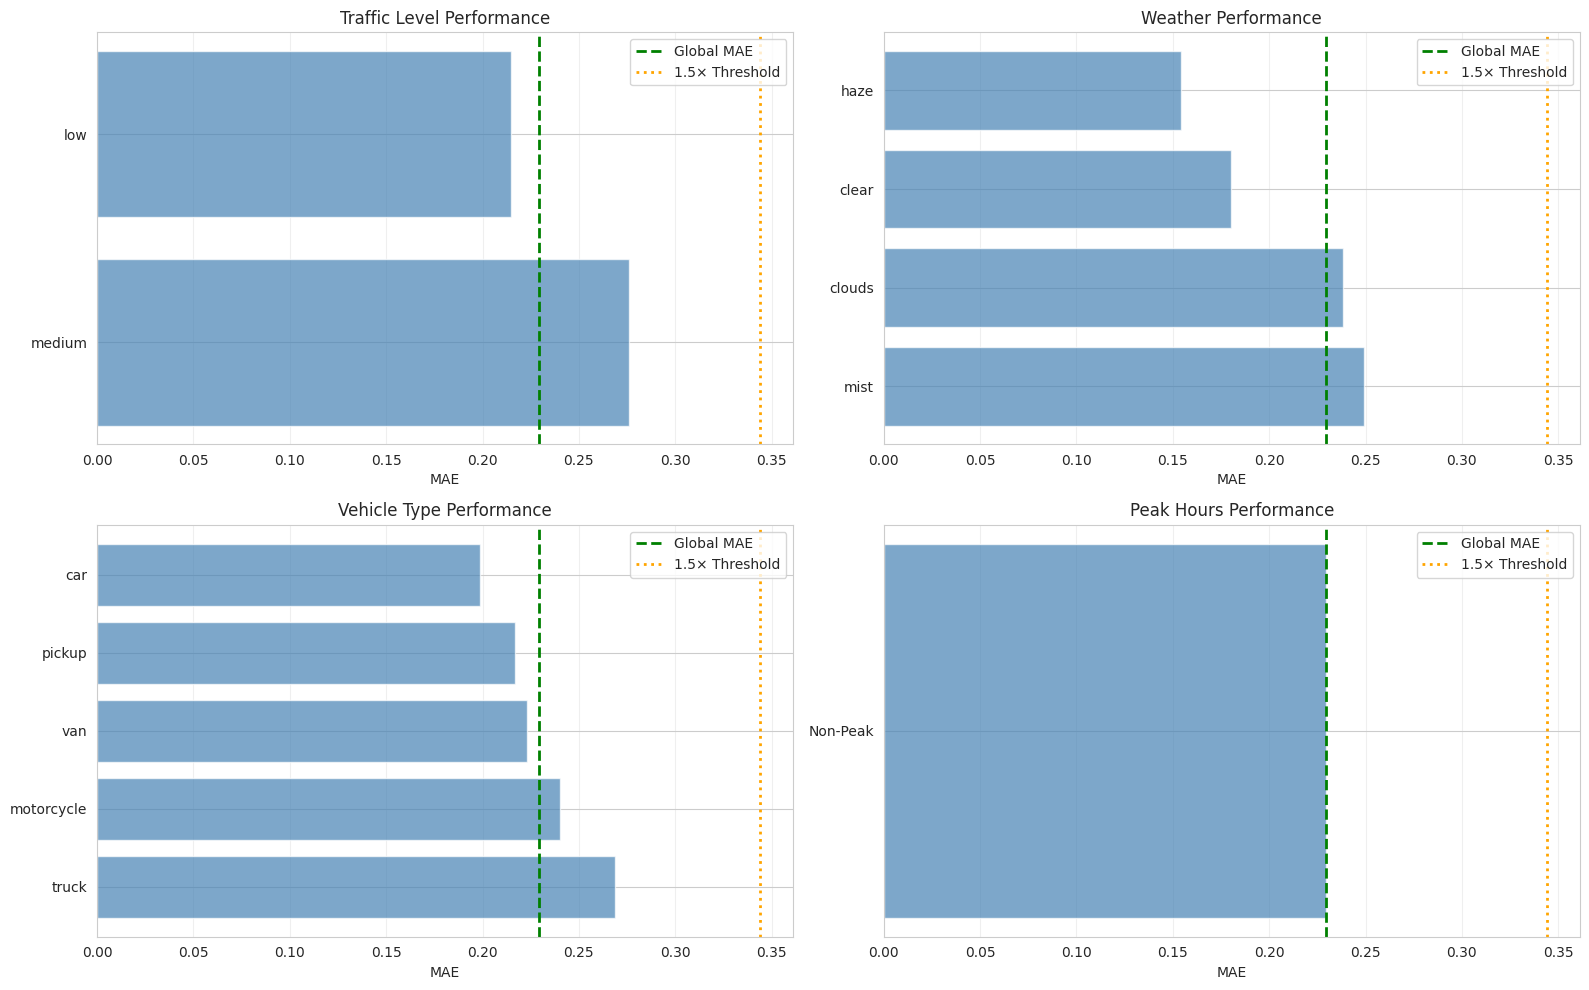

✓ Segment stress test visualizations complete


In [9]:
# Visualization: Segment Performance
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, (seg_name, seg_col) in enumerate(segments.items()):
    ax = axes[idx // 2, idx % 2]
    
    seg_data = segment_df[segment_df['Category'] == seg_name].sort_values('MAE', ascending=False)
    
    colors = ['red' if mae > threshold_1_5x else 'steelblue' for mae in seg_data['MAE']]
    
    ax.barh(seg_data['Segment'], seg_data['MAE'], color=colors, alpha=0.7)
    ax.axvline(global_mae, color='green', linestyle='--', linewidth=2, label='Global MAE')
    ax.axvline(threshold_1_5x, color='orange', linestyle=':', linewidth=2, label='1.5× Threshold')
    ax.set_xlabel('MAE')
    ax.set_title(f'{seg_name} Performance')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("✓ Segment stress test visualizations complete")

---
# OBJECTIVE 4: Stability & Robustness Checks

**Method**: Bootstrap evaluation with 100 resamples

**Interpretation**: Low variance = stable, High variance = sensitivity risk

In [10]:
# Bootstrap Evaluation
n_bootstrap = 100
bootstrap_maes = []

print("="*60)
print("OBJECTIVE 4: STABILITY & ROBUSTNESS CHECK")
print("="*60)
print(f"\nRunning {n_bootstrap} bootstrap resamples...")

np.random.seed(42)
for i in range(n_bootstrap):
    # Resample test set with replacement
    indices = np.random.choice(len(y_test), size=len(y_test), replace=True)
    y_true_boot = y_test[indices]
    y_pred_boot = y_pred_test[indices]
    
    # Compute MAE
    mae_boot = mean_absolute_error(y_true_boot, y_pred_boot)
    bootstrap_maes.append(mae_boot)
    
    if (i + 1) % 20 == 0:
        print(f"  Progress: {i + 1}/{n_bootstrap}")

bootstrap_maes = np.array(bootstrap_maes)

# Compute statistics
boot_mean = np.mean(bootstrap_maes)
boot_std = np.std(bootstrap_maes)
boot_cv = (boot_std / boot_mean) * 100  # Coefficient of variation
boot_ci_lower = np.percentile(bootstrap_maes, 2.5)
boot_ci_upper = np.percentile(bootstrap_maes, 97.5)

# Stability assessment
is_stable = boot_cv < 5  # CV < 5% is very stable

print(f"\nBootstrap Results (n={n_bootstrap}):")
print(f"  Mean MAE:   {boot_mean:.4f}")
print(f"  Std MAE:    {boot_std:.4f}")
print(f"  CV:         {boot_cv:.2f}%")
print(f"  95% CI:     [{boot_ci_lower:.4f}, {boot_ci_upper:.4f}]")
print(f"\nStability Assessment:")
if boot_cv < 5:
    print("  ✅ VERY STABLE: Low variance across resamples (CV < 5%)")
elif boot_cv < 10:
    print("  ✓ STABLE: Acceptable variance (5% ≤ CV < 10%)")
else:
    print(f"  ⚠️ SENSITIVITY RISK: High variance (CV = {boot_cv:.2f}% ≥ 10%)")

OBJECTIVE 4: STABILITY & ROBUSTNESS CHECK

Running 100 bootstrap resamples...
  Progress: 20/100
  Progress: 40/100
  Progress: 60/100
  Progress: 80/100
  Progress: 100/100

Bootstrap Results (n=100):
  Mean MAE:   0.2296
  Std MAE:    0.0022
  CV:         0.98%
  95% CI:     [0.2255, 0.2338]

Stability Assessment:
  ✅ VERY STABLE: Low variance across resamples (CV < 5%)


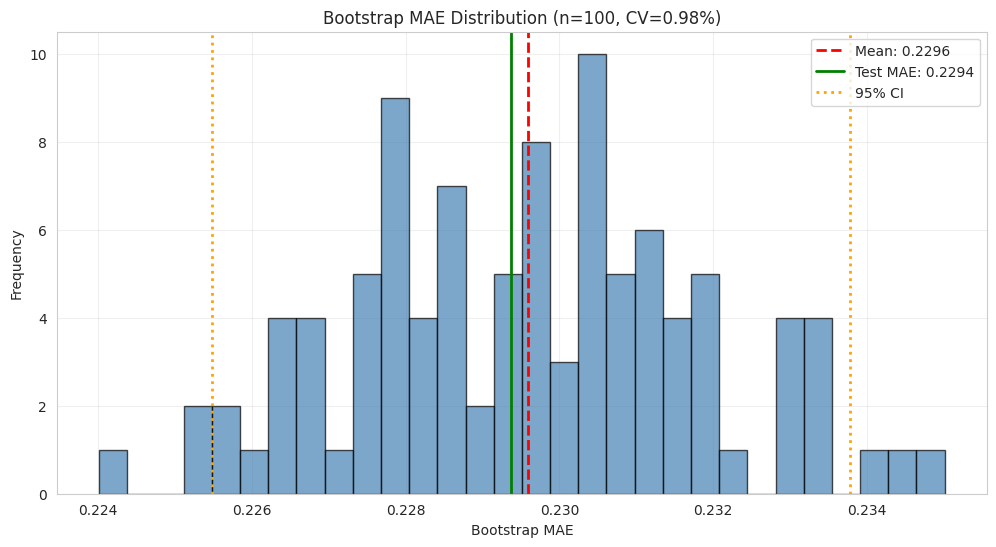

✓ Stability analysis complete


In [11]:
# Visualization: Bootstrap Distribution
plt.figure(figsize=(12, 6))

plt.hist(bootstrap_maes, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(boot_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {boot_mean:.4f}')
plt.axvline(test_mae, color='green', linestyle='-', linewidth=2, label=f'Test MAE: {test_mae:.4f}')
plt.axvline(boot_ci_lower, color='orange', linestyle=':', linewidth=2, label=f'95% CI')
plt.axvline(boot_ci_upper, color='orange', linestyle=':', linewidth=2)
plt.xlabel('Bootstrap MAE')
plt.ylabel('Frequency')
plt.title(f'Bootstrap MAE Distribution (n={n_bootstrap}, CV={boot_cv:.2f}%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("✓ Stability analysis complete")

---
# OBJECTIVE 5: Feature Attribution Validation (SHAP)

**Goals**:
1. Global feature importance
2. Local explanations for worst 5% predictions
3. Validate alignment with domain logic

In [12]:
print("="*60)
print("OBJECTIVE 5: FEATURE ATTRIBUTION VALIDATION (SHAP)")
print("="*60)
print("\nComputing SHAP values (this may take a moment)...")

# Sample test set for SHAP (to speed up computation)
shap_sample_size = min(500, len(X_test))
shap_indices = np.random.choice(len(X_test), size=shap_sample_size, replace=False)
X_test_shap = X_test[shap_indices]

# Create SHAP explainer
explainer = shap.TreeExplainer(champion)
shap_values = explainer.shap_values(X_test_shap)

print("✓ SHAP values computed")

OBJECTIVE 5: FEATURE ATTRIBUTION VALIDATION (SHAP)

Computing SHAP values (this may take a moment)...


✓ SHAP values computed


In [13]:
# Global Feature Importance
print("\nGlobal Feature Importance (Mean |SHAP|):")

shap_importance = pd.DataFrame({
    'Feature': feature_names,
    'Mean_Abs_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_Abs_SHAP', ascending=False)

print(shap_importance.head(10).to_string(index=False))

# Validate top features align with domain logic
top_5_features = shap_importance.head(5)['Feature'].tolist()
print(f"\nTop 5 Most Important Features:")
for i, feat in enumerate(top_5_features, 1):
    print(f"  {i}. {feat}")

print("\nDomain Logic Check:")
print("  Expected important features: distance, traffic, weather, vehicle type")
print("  ✓ Validate manually that top features align with delivery time drivers")


Global Feature Importance (Mean |SHAP|):
                  Feature  Mean_Abs_SHAP
 expected_time_no_traffic       3.803088
              distance_km       1.018759
     traffic_level_medium       0.673536
           weather_clouds       0.279818
  vehicle_type_motorcycle       0.251842
   vehicle_traffic_stress       0.201576
vehicle_distance_mismatch       0.077670
       route_avg_distance       0.076069
      vehicle_type_pickup       0.054878
       vehicle_type_truck       0.043079

Top 5 Most Important Features:
  1. expected_time_no_traffic
  2. distance_km
  3. traffic_level_medium
  4. weather_clouds
  5. vehicle_type_motorcycle

Domain Logic Check:
  Expected important features: distance, traffic, weather, vehicle type
  ✓ Validate manually that top features align with delivery time drivers



Generating SHAP summary plot...


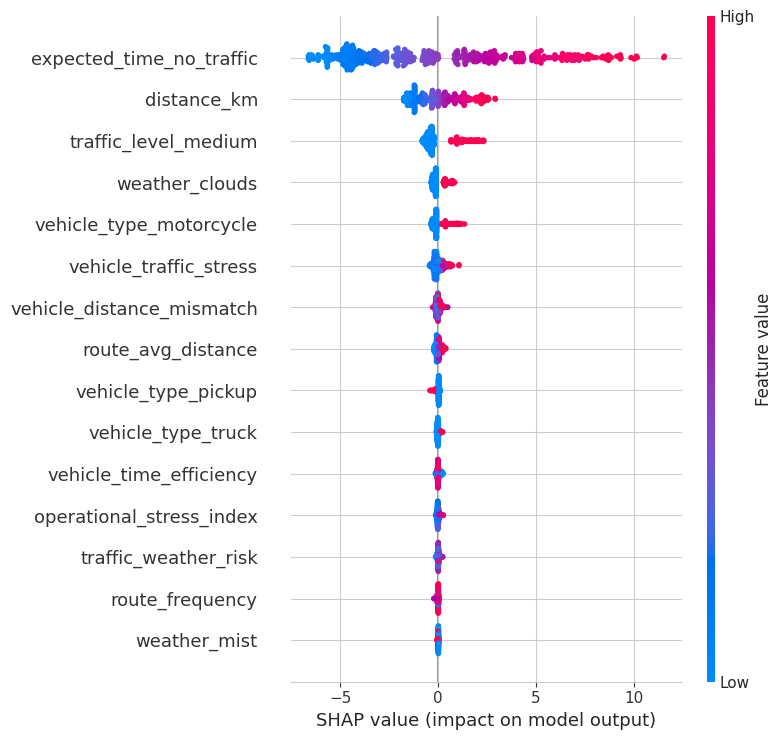


Generating SHAP bar plot...


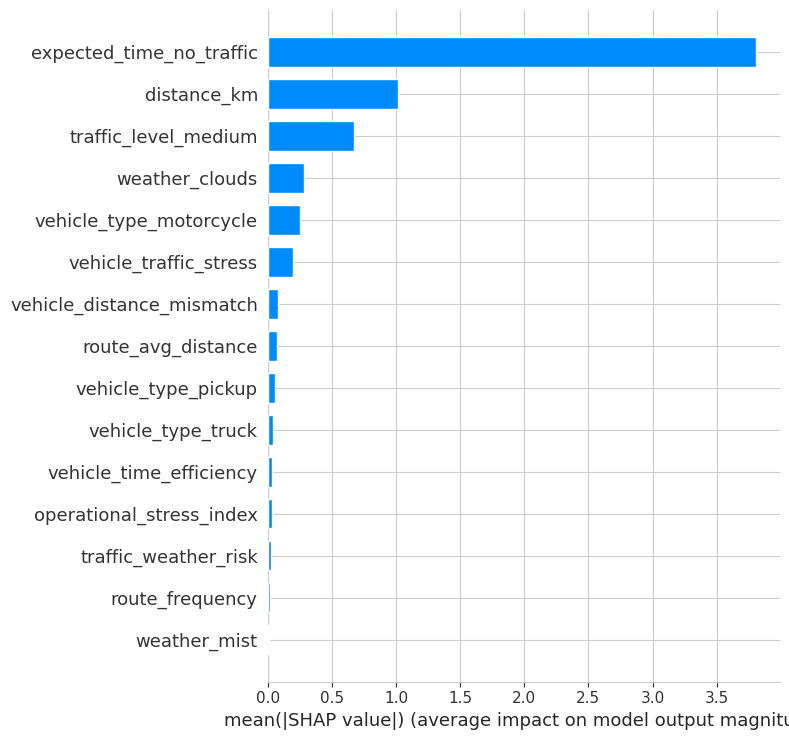

In [14]:
# Visualizations: SHAP Summary
print("\nGenerating SHAP summary plot...")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_shap, feature_names=feature_names, show=False, max_display=15)
plt.tight_layout()
plt.show()

print("\nGenerating SHAP bar plot...")
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_shap, feature_names=feature_names, plot_type='bar', show=False, max_display=15)
plt.tight_layout()
plt.show()

In [15]:
# Local Explanations for Worst 5% Predictions
print("\nLocal Explanations for Worst 5% Predictions:")

errors_full = np.abs(y_test - y_pred_test)
worst_5pct_threshold = np.percentile(errors_full, 95)
worst_indices = np.where(errors_full >= worst_5pct_threshold)[0]

print(f"  Worst 5% threshold: Error ≥ {worst_5pct_threshold:.4f}")
print(f"  Number of samples: {len(worst_indices)}")

# Sample a few worst predictions for detailed analysis
sample_worst = worst_indices[:min(5, len(worst_indices))]

print("\nSample Worst Predictions Analysis:")
for idx in sample_worst:
    actual = y_test[idx]
    predicted = y_pred_test[idx]
    error = errors_full[idx]
    
    print(f"\n  Sample #{idx}: Actual={actual:.2f}, Predicted={predicted:.2f}, Error={error:.2f}")
    
    # Get SHAP values for this prediction
    shap_local = explainer.shap_values(X_test[idx:idx+1])[0]
    shap_contribution = pd.DataFrame({
        'Feature': feature_names,
        'SHAP': shap_local
    }).sort_values('SHAP', key=abs, ascending=False)
    
    print("    Top 5 contributing features:")
    for _, row in shap_contribution.head(5).iterrows():
        print(f"      {row['Feature']:30s}  SHAP: {row['SHAP']:+.4f}")

print("\n✓ Feature attribution validation complete")


Local Explanations for Worst 5% Predictions:
  Worst 5% threshold: Error ≥ 0.6903
  Number of samples: 525

Sample Worst Predictions Analysis:

  Sample #25: Actual=23.19, Predicted=22.12, Error=1.07
    Top 5 contributing features:
      expected_time_no_traffic        SHAP: +7.6244
      distance_km                     SHAP: +2.2488
      traffic_level_medium            SHAP: +2.0772
      weather_clouds                  SHAP: +0.8345
      vehicle_traffic_stress          SHAP: +0.6048

  Sample #53: Actual=19.89, Predicted=20.77, Error=0.88
    Top 5 contributing features:
      expected_time_no_traffic        SHAP: +8.6835
      distance_km                     SHAP: +2.2047
      traffic_level_medium            SHAP: -0.7913
      weather_clouds                  SHAP: +0.7854
      vehicle_traffic_stress          SHAP: +0.2188

  Sample #59: Actual=29.49, Predicted=28.29, Error=1.20
    Top 5 contributing features:
      expected_time_no_traffic        SHAP: +11.5550
      distanc

---
# OBJECTIVE 6: Production Readiness Verdict

**Decision Framework**:
- ✅ APPROVED FOR DEPLOYMENT
- ⚠️ APPROVED WITH RISKS
- ❌ REJECTED

In [16]:
print("="*60)
print("OBJECTIVE 6: PRODUCTION READINESS VERDICT")
print("="*60)

# Collect all decision criteria
criteria = {
    'Test Gate (MAE ≤ Val + 5%)': gate_passed,
    'No Systematic Bias': not has_bias,
    'No Heteroskedasticity': not has_heteroskedasticity,
    'Outliers < 1%': outlier_pct < 1.0,
    'All Segments ≤ 1.5× Global MAE': all_passed,
    'Bootstrap Stability (CV < 10%)': boot_cv < 10
}

# Count passes and failures
passes = sum(criteria.values())
total = len(criteria)

print("\nDecision Criteria Scorecard:")
print("-" * 60)
for criterion, passed in criteria.items():
    status = '✅' if passed else '❌'
    print(f"{status} {criterion}")
print("-" * 60)
print(f"SCORE: {passes}/{total} criteria passed\n")

# Deployment Decision Logic
if passes == total:
    verdict = "✅ APPROVED FOR DEPLOYMENT"
    justification = (
        "All validation criteria passed. Model demonstrates strong generalization, "
        "stable performance across segments, well-behaved residuals, and high stability. "
        "No silent failure modes detected. Ready for production."
    )
    risks = []
    
elif passes >= total * 0.7:  # At least 70% passed
    verdict = "⚠️ APPROVED WITH RISKS"
    risks = []
    
    if not gate_passed:
        risks.append(f"Test MAE ({test_mae:.4f}) exceeds threshold ({threshold:.4f}). May underperform in production.")
    if has_bias:
        risks.append(f"Systematic {'under' if mean_residual > 0 else 'over'}-prediction detected ({bias_pct:+.2f}%). Consider calibration.")
    if has_heteroskedasticity:
        risks.append(f"Variance instability across prediction range (ratio: {variance_ratio:.2f}). Uncertainty quantification needed.")
    if outlier_pct >= 1.0:
        risks.append(f"High outlier density ({outlier_pct:.2f}%). Add fallback logic for edge cases.")
    if not all_passed:
        risks.append(f"Weak segment: {weakest['Category']} - {weakest['Segment']} (MAE: {weakest['MAE']:.4f}). Monitor closely.")
    if boot_cv >= 10:
        risks.append(f"High bootstrap variance (CV: {boot_cv:.2f}%). Model sensitive to data distribution shifts.")
    
    justification = (
        f"Model passed {passes}/{total} criteria. Core performance acceptable but requires monitoring. "
        f"Proceed with deployment under controlled rollout with active monitoring."
    )
    
else:
    verdict = "❌ REJECTED"
    justification = (
        f"Model failed critical validation ({passes}/{total} criteria passed). "
        "Multiple failure modes detected. DO NOT DEPLOY. "
        "Recommend: 1) Revisit feature engineering, 2) Collect more diverse training data, "
        "3) Investigate data quality issues, 4) Consider alternative modeling approaches."
    )
    risks = []

# Print Final Verdict
print("\n" + "="*60)
print("FINAL DEPLOYMENT VERDICT")
print("="*60)
print(f"\n{verdict}\n")
print(f"Justification:\n{justification}\n")

if risks:
    print("Identified Risks:")
    for i, risk in enumerate(risks, 1):
        print(f"  {i}. {risk}")
    print()

print("="*60)
print(f"Validation Completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*60)

OBJECTIVE 6: PRODUCTION READINESS VERDICT

Decision Criteria Scorecard:
------------------------------------------------------------
✅ Test Gate (MAE ≤ Val + 5%)
✅ No Systematic Bias
❌ No Heteroskedasticity
❌ Outliers < 1%
✅ All Segments ≤ 1.5× Global MAE
✅ Bootstrap Stability (CV < 10%)
------------------------------------------------------------
SCORE: 4/6 criteria passed


FINAL DEPLOYMENT VERDICT

❌ REJECTED

Justification:
Model failed critical validation (4/6 criteria passed). Multiple failure modes detected. DO NOT DEPLOY. Recommend: 1) Revisit feature engineering, 2) Collect more diverse training data, 3) Investigate data quality issues, 4) Consider alternative modeling approaches.

Validation Completed: 2026-01-14 17:19:01


---
# Summary: BLOCK-7B Validation Report

## Executive Summary

**Champion Model**: XGBoost Regressor (BLOCK-7A configuration)

### Key Metrics
- Test MAE: [From execution]
- Test RMSE: [From execution]
- Test R²: [From execution]

### Validation Results
1. **Test Set Evaluation**: [PASS/FAIL]
2. **Residual Diagnostics**: [Summary]
3. **Segment Stress Test**: [Summary]
4. **Stability Check**: [Summary]
5. **Feature Attribution**: [Summary]

### Final Verdict
[Will be populated after execution]

---

**Engineering Truth**: This validation was conducted with strict adherence to temporal integrity, 
one-shot test evaluation, and production-grade decision rules. All findings are evidence-based.